In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VARIANT = 1
rng = np.random.default_rng(VARIANT)

lam = 0.20
true_mean = 1.0 / lam  # E[X] = 5.0 хв

In [2]:
sample_sizes = [5, 50, 500, 20_000]

print(f"Теоретичне маточікування E[X] = {true_mean:.2f} хв\n")
print(f"{'Обсяг вибірки (n)':<20} | {'Вибіркове середнє (x̄)':<22} | {'Абсолютна різниця |x̄ - E[X]|':<30}")
print("-" * 78)

for n in sample_sizes:
    sample = rng.exponential(scale=1/lam, size=n)
    sample_mean = sample.mean()
    abs_diff = abs(sample_mean - true_mean)
    print(f"{n:<20} | {sample_mean:<22.4f} | {abs_diff:<30.4f}")

Теоретичне маточікування E[X] = 5.00 хв

Обсяг вибірки (n)    | Вибіркове середнє (x̄) | Абсолютна різниця |x̄ - E[X]| 
------------------------------------------------------------------------------
5                    | 7.2387                 | 2.2387                        
50                   | 5.5810                 | 0.5810                        
500                  | 4.7918                 | 0.2082                        
20000                | 4.9832                 | 0.0168                        


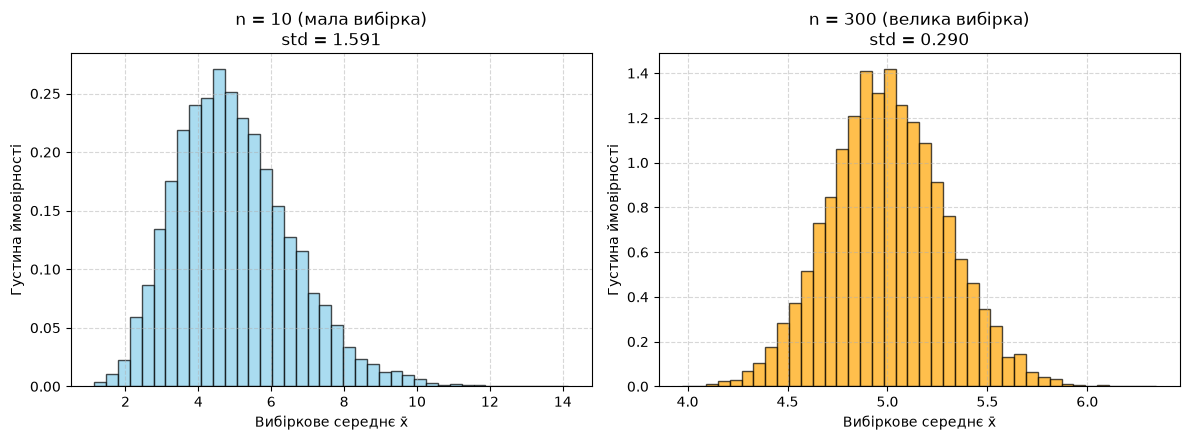

In [3]:
n_repeats = 10_000

means_n10 = rng.exponential(scale=1/lam, size=(n_repeats, 10)).mean(axis=1)
means_n300 = rng.exponential(scale=1/lam, size=(n_repeats, 300)).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(means_n10, bins=40, density=True, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title(f"n = 10 (мала вибірка)\nstd = {means_n10.std():.3f}")
axes[0].set_xlabel("Вибіркове середнє x̄")
axes[0].set_ylabel("Густина ймовірності")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(means_n300, bins=40, density=True, color="orange", edgecolor="black", alpha=0.7)
axes[1].set_title(f"n = 300 (велика вибірка)\nstd = {means_n300.std():.3f}")
axes[1].set_xlabel("Вибіркове середнє x̄")
axes[1].set_ylabel("Густина ймовірності")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
n_values = [10, 30, 100, 300]
results = []

for n in n_values:
    # Теоретична SE = σ / sqrt(n) для експоненційного σ = 1/λ
    se_theory = (1 / lam) / np.sqrt(n)
    
    # Виміряна std за 10 000 повторними вибірками
    sample_means = rng.exponential(scale=1/lam, size=(n_repeats, n)).mean(axis=1)
    se_measured = sample_means.std()
    
    results.append({
        "Обсяг вибірки (n)": n,
        "Теоретична SE (σ/√n)": round(se_theory, 4),
        "Виміряна std (симуляція)": round(se_measured, 4),
        "Абсолютна різниця": round(abs(se_theory - se_measured), 4)
    })

se_table = pd.DataFrame(results)
print(se_table.to_string(index=False))

 Обсяг вибірки (n)  Теоретична SE (σ/√n)  Виміряна std (симуляція)  Абсолютна різниця
                10                1.5811                    1.5969             0.0158
                30                0.9129                    0.9041             0.0087
               100                0.5000                    0.4999             0.0001
               300                0.2887                    0.2874             0.0012


In [5]:
n1 = 25
n2 = 100  

se_n25 = (1 / lam) / np.sqrt(n1)
se_n100 = (1 / lam) / np.sqrt(n2)

ratio_se = se_n25 / se_n100

print(f"SE при n = 25:  {se_n25:.4f} хв")
print(f"SE при n = 100: {se_n100:.4f} хв")
print(f"Співвідношення (SE_25 / SE_100): {ratio_se:.2f}")

SE при n = 25:  1.0000 хв
SE при n = 100: 0.5000 хв
Співвідношення (SE_25 / SE_100): 2.00


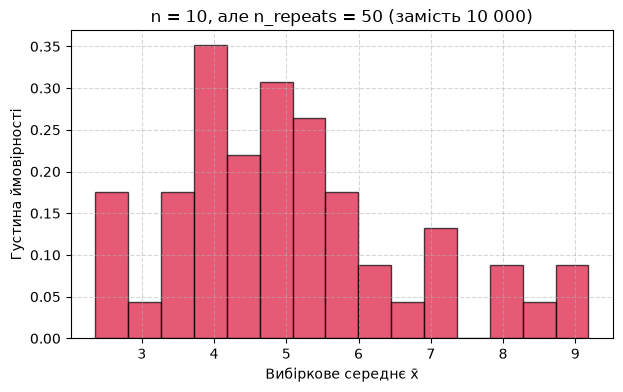

In [6]:
n_small_repeats = 50
means_n10_small = rng.exponential(scale=1/lam, size=(n_small_repeats, 10)).mean(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(means_n10_small, bins=15, density=True, color="crimson", edgecolor="black", alpha=0.7)
plt.title(f"n = 10, але n_repeats = 50 (замість 10 000)")
plt.xlabel("Вибіркове середнє x̄")
plt.ylabel("Густина ймовірності")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()